W tym notatniku zastosujemy klasyfikacje binarną. Celem tego kodu będzie zbudowanie modelu uczenia
maszynowego zdolnego do odróznienia leków zatwierdzonych przez FDA (Amerykańską Agencję ds. Żywności i  Leków) od cząsteczek, które nie przeszły testów klinicznych ze względu na zbyt wysoką toksyczność. Zastosowana zostanie zwiększona rozdzielczość reprezentacji (nBits = 2048), aby zminimalizować ryzyko kolizji bitów i błędnej generalizacji strukturalnej (tak jak to było w notatniku Day10). Użyje zamiast RandomForestReggresor - RandomForestClassifier, do wyszukiwania nieliniowych korelacji pomiędzy obecnością konkretnych fragmentów strukturalnych a toksycznościa. Użyję analizy zwanej Macierzą Błędu (Confusion Matrix). Zobaczę czy model zakwalifikuję cząsteczki toksyczne jako bezpieczne i na odwrót.
CZEMU JA WCZESNIEJ NIE ROBIŁEM KOMÓRKI TYPU MARKDOWN

Pierwszorzędnie sprawdzam jak wygląda tabela oraz czy python widzi ją poprawnie.
FDA_APPROVED = 1 = zostały uznane za bezpieczne
CT_TOX= 1 = zostały uznane za toksyczne

In [4]:
import pandas as pd
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz"
df = pd.read_csv(url)
print(f"Rozmiar tabeli (wiersze, kolumny): {df.shape}")
display(df.head())

Rozmiar tabeli (wiersze, kolumny): (1484, 3)


,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0
3,[H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])...,1,0
4,[H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(...,1,0


Nastepnie sprawdze czy baza danych jest "legit", czy nie zawiera literówek lub błedów które rdkit nie jest w stanie zinterpretować.

In [5]:
from rdkit import Chem
import numpy as np

print("Zaczynam weryfikację bazy danych...")

czyste_smiles = []
toksycznosc = []

for index, row in df.iterrows(): #iterrows - czytanie z góry na dół
    sml = row['smiles']
    tox_label = row['CT_TOX']
    mol = Chem.MolFromSmiles(sml)

    if mol is not None:
        czyste_smiles.append(sml),
        toksycznosc.append(tox_label),

y = np.array(toksycznosc) #Zmiana na wektor liczbowy
print(f"Odrzucono {len(df) - len(czyste_smiles)} błędnych cząsteczek.")
print(f"Pozostało {len(czyste_smiles)} poprawnych struktur do treningu.")
        

Zaczynam weryfikację bazy danych...


[14:21:58] Explicit valence for atom # 0 N, 4, is greater than permitted
[14:21:58] Can't kekulize mol.  Unkekulized atoms: 9


Odrzucono 4 błędnych cząsteczek.
Pozostało 1480 poprawnych struktur do treningu.


[14:21:58] Can't kekulize mol.  Unkekulized atoms: 4
[14:21:58] Can't kekulize mol.  Unkekulized atoms: 4


Zamienię obiekt molekuł na fingerprinty morgana, trzeba przetłumaczyć 1480 cząsteczek na ciąg zer i jedynek. Wyciągam wnioski z poprzedniej lekcji i tutaj od razu użyje 2048 bitów (podwoje liczbe pudełek)

In [6]:
from rdkit.Chem import rdFingerprintGenerator

print("Zmieniam cząsteczki na wektory 0 i 1...")
morgan_gen= rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

X_list = [] #Macierz wszystkich danych wejściowych

for sml in czyste_smiles:
    mol = Chem.MolFromSmiles(sml)
    fp = morgan_gen.GetFingerprint(mol)
    X_list.append(list(fp)) #Zmieniam fingerprinty na zwykła listę zer i jedynek i dodaje do głownej listy

X=np.array(X_list) #Zmieniam listę w wielką, dwuwymiarową macierz

print(f"Kształt macierzy danych X:{X.shape}")
print(f"Kształt wektora celów y:{y.shape}")
    




Zmieniam cząsteczki na wektory 0 i 1...
Kształt macierzy danych X:(1480, 2048)
Kształt wektora celów y:(1480,)


Otrzymaliśmy macierz gdzie są 1480 (cząsteczek) wierszy oraz 2048 kolumn (bity). Wektor celów ma 1480 wierszy - odpowiada to wartościa CT_TOX = 1 albo 0 dla każdej z 1480 cząsteczek. Wykonam teraz trening modelu.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier #Import lasu losowego poprzedni model w Day10 szukał liczby po przecinku, ten model szuka sztywnej etykiety trucizna czy bezpieczne

print("Dzielenie danych na zbiór treningowy i testowy")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Dane dla modelu do nauki 20% test 80% nauka

print(f"Dane do nauki: {X_train.shape[0]} cząsteczek")
print(f"Dane do egzaminu: {X_test.shape[0]} cząsteczek")

model = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimator=100 - powstaje 100 małych drzew decyzyjnych. Tworzymy "pusty mózg"

print("\nRozpoczynam trening modelu...")

model.fit(X_train, y_train) #szukanie matematycznych dowodów na to dlaczego y_train ma w danym miejscu 1 bądź 0
print("Trening zakończony sukcesem")

Dzielenie danych na zbiór treningowy i testowy
Dane do nauki: 1184 cząsteczek
Dane do egzaminu: 296 cząsteczek

Rozpoczynam trening modelu...
Trening zakończony sukcesem


Trening modelu zakończony sukcesem, teraz sprawdźmy czy model rzeczywiście nie popełnił błędu. Żeby ocenić nasz klasyfikator użyje Macierz Błędu (Confusion Matrix). Pokaże nam ile razy model miał rację i jakiego rodzaju błedy popełnia.

Rozpoczynam egzamin...
Ogólna skuteczność modelu: 91.55%



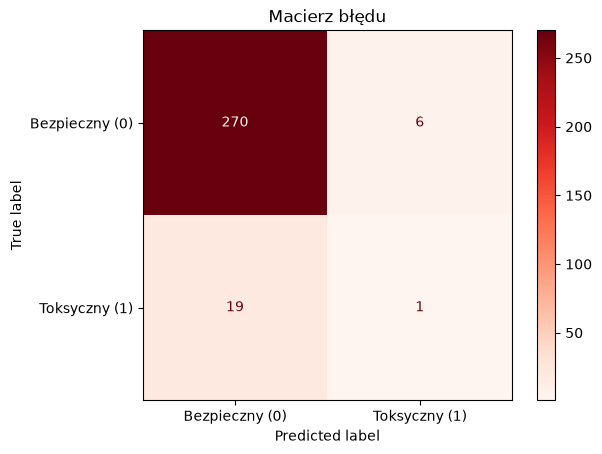

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
#accucary_score-procent poprawnych odpowiedzi, confusion_matrix-surowa tabela błedów, confusio_nmatrix_display-maluje tą tabele
print("Rozpoczynam egzamin...")

y_pred = model.predict(X_test)#Podajemy modelowi nasze 20% ukrytych cząsteczek (X_test), a on dla każdej z nich generuje własną decyzję (0 lub 1) i zapisuje ją w zmiennej y_pred

dokladnosc = accuracy_score(y_test, y_pred)#Porównywanie rozwiązanie modelu y_pred z y_test)
print(f"Ogólna skuteczność modelu: {dokladnosc*100:.2f}%\n")

cm = confusion_matrix(y_test, y_pred) #Tworzy kwadratową tabele która dzieli wyniki i maluje je odcieniami.

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])
disp.plot(cmap=plt.cm.Reds)

plt.title("Macierz błędu")
plt.show()

Nie podoba mi się fakt, że model przewidział 19 związków jako bezpieczna, a w rzeczywistości były one toksyczne oraz martwi mnei to ze tylko jeden związek udało sie przewidzieć jako toksyczny.
AI zaproponowało mi użycie parametru class_weight, żeby uniknąć błednej analizy i powiedzieć mu żę pomyłka przywykrywaniu substancji toksycznych boli mocniej.
    

Tworzymy nowy model ze zbalansowanymi wagami...
Uczymy model na nowo...
Nowa skuteczność modelu wynosi:91.89%



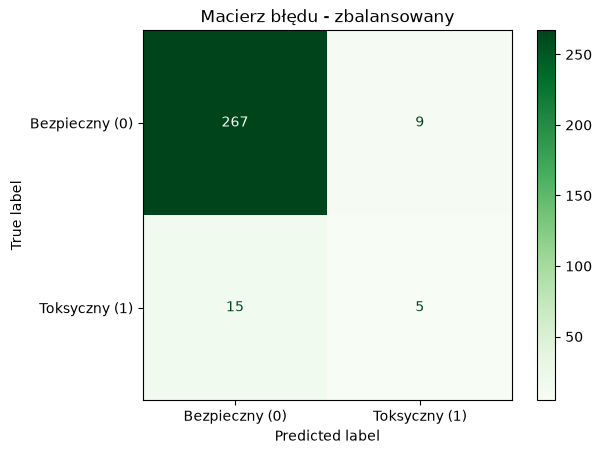

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Tworzymy nowy model ze zbalansowanymi wagami...")

model_zbalansowany = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
print("Uczymy model na nowo...")

model_zbalansowany.fit(X_train, y_train)

y_pred_bal = model_zbalansowany.predict(X_test)

dokladnosc_bal = accuracy_score(y_test, y_pred_bal)
print(f"Nowa skuteczność modelu wynosi:{dokladnosc_bal*100:.2f}%\n")

cm_bal = confusion_matrix(y_test, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['Bezpieczny (0)', 'Toksyczny (1)'])
disp_bal.plot(cmap=plt.cm.Greens)

plt.title('Macierz błędu - zbalansowany')
plt.show()

Wnioski:
    1. Model początkowo reprezentował tzw. accuracy paradox – jego ogólna skuteczność wydawała się wysoka, ponieważ bezbłędnie potrafił wskazać leki bezpieczne (270 trafień w lewym górnym rogu).Zignorował on jednak mniejszość. Na 20 rzeczywistych przypadków toksycznych (19 + 1) zauważył zaledwie 1 przypadek (prawy dolny róg), a aż 19 próbek toksycznych błędnie uznał za bezpieczne (lewy dolny róg).Domyślny algorytm poszedł na łatwiznę – statystycznie opłacało mu się zgadywać bezpieczne odpowiedzi, co czyniło go bezużytecznym do wykrywania realnych zagrożeń.
    2. Zastosowanie parametru class_weight='balanced' zmusiło model do traktowania rzadkich próbek toksycznych z większym priorytetem.Liczba wykrytych substancji toksycznych wzrosła z 1 do 5, a liczba niebezpiecznych przeoczeń spadła z 19 do 15. Jednocześnie model zaczął generować nieco więcej fałszywych alarmów (wzrost z 6 do 9).Algorytm przestał być „leniwy” i zaczął realnie analizować cechy chemiczne pod kątem zagrożeń, kosztem podwyższenia czujności i częstszego mylenia bezpiecznych leków z toksycznymi.
    3. Model statystyczny bez ingerencji ludzkiej optymalizuje ogólne cyfry, co w farmacji mogłoby prowadzić do katastrofy (przepuszczania trucizn).Nawet po zbalansowaniu wag, model nadal popełnia błędy (15 przeoczonych toksyn). Dowodzi to, że surowe narzędzie ML nie może stanowić ostatecznej wyroczni – wymaga stałego nadzoru analityka oraz traktowania jako wstępne, filtrujące sitko chemiczne, a nie ostateczna prawda laboratoryjna.
    4. 15 pomyłek to nadal jest wynik niakceptowalny!!!.